In [1]:
import os
import random
import string
import math

import hail as hl
from ukb_utils import hail_init
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from ko_utils import ko
from ko_utils import io
from ko_utils import samples
from ko_utils.ko import PLOF_CSQS, MISSENSE_CSQS, SYNONYMOUS_CSQS, OTHER_CSQS
import scipy.stats as stats

In [2]:
os.chdir('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')
hail_init.hail_bmrc_init('logs/hail/hail_test_export.log', 'GRCh38')

Running on Apache Spark version 3.1.2
SparkUI available at http://compa043.hpc.in.bmrc.ox.ac.uk:4040
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.77-684f32d73643
LOGGING: writing to logs/hail/hail_test_export.log


In [3]:
def normalize_dosages(dosages):
    r"""Normalizes dosages to have mean 0 and variance 1 at each SNP Parameters
    """
    mt = dosages._indices.source
    mt = mt.annotate_rows(**{'gt_stats_'+tid: hl.agg.stats(mt.DS)})
    mt = mt.annotate_entries(norm_ds=(mt.DS-mt.DS.mean)/mt.DS.stdev)
    return mt

In [4]:
input_path = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/prs/hapmap/ukb_500k/fitting/ukb_hapmap_500k_eur_chr21"
input_type = "plink"
phenotypes = "data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz"

In [9]:
mt = io.import_table(input_path, input_type)

2022-06-21 15:48:42 Hail: INFO: Found 246271 samples in fam file.
2022-06-21 15:48:42 Hail: INFO: Found 16727 variants in bim file.


In [11]:
if phenotypes:
    ht = hl.import_table(phenotypes,
                 types={'eid': hl.tstr},
                 missing=["",'""',"NA"],
                 impute=True,
                 force=True,
                 key='eid'
                 )
    mt = mt.annotate_cols(pheno=ht[mt.s])
else:
    raise ValueError("param 'phenotypes' is not set! ")

2022-06-21 15:50:01 Hail: WARN: file 'file:/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz' is 343.2M
  It will be loaded serially (on one core) due to usage of the 'force' argument.
  If it is actually block-gzipped, either rename to .bgz or use the 'force_bgz'
  argument.
2022-06-21 15:50:02 Hail: INFO: Reading table to impute column types
2022-06-21 15:50:33 Hail: WARN: file 'file:/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz' is 343.2M
  It will be loaded serially (on one core) due to usage of the 'force' argument.
  If it is actually block-gzipped, either rename to .bgz or use the 'force_bgz'
  argument.
2022-06-21 15:50:33 Hail: INFO: Loading 382 fields. Counts by type:
  float64: 372
  int32: 7
  bool: 2
  str: 1


In [13]:
ht.count()

176594

In [12]:
mt.count()

(16727, 246271)

# Standard simulation of genotypes using Hail

In [5]:
# parameters
h2 = 0.2
pi = None #0.002
n = 1000

In [6]:
# simulate SNPs 
mt = hl.balding_nichols_model(1, 5000, n, reference_genome='GRCh38')
mt = mt.transmute_entries(GT = ko.set_to_phased_call(mt.GT))
#mt = hl.experimental.ldscsim.make_betas(mt, h2, pi = pi)[0]

2022-06-30 11:20:58 Hail: INFO: balding_nichols_model: generating genotypes for 1 populations, 5000 samples, and 1000 variants...


5.0

In [165]:
# standardize SNPs
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

In [166]:
# add noise component
mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
mt = mt.annotate_cols(y=mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))
print(np.var(mt.y.collect()))
print(np.var(mt.y_no_noise.collect()))

1.014615656043278
0.21255572008547832


In [749]:
ht = hl.linear_regression_rows(y=mt.y,
                               x=mt.GT.n_alt_alleles(),
                                covariates=[1])

2022-04-05 11:46:35 Hail: INFO: Coerced sorted dataset
2022-04-05 11:46:36 Hail: INFO: linear_regression_rows: running on 5000 samples for 1 response variable y,
    with input variable x, and 1 additional covariate...


In [750]:
rows = ht.count()
p_expected = [ -math.log10((x+1) / rows) for x in range(rows)]
p_observed = [ -math.log10(x) for x in ht.p_value.collect()]
p_observed.sort()
p_expected.sort()
x = p_expected[::-1]
y = p_observed[::-1]

In [751]:
beta = mt.beta.collect()
true_hits = np.where(np.abs(np.array(beta)) > 0)[0]

2022-04-05 11:46:37 Hail: INFO: Coerced sorted dataset


In [752]:
ps = np.array(p_observed)
bonf = -math.log10(0.05/rows)
hits = np.where(ps > bonf)[0]

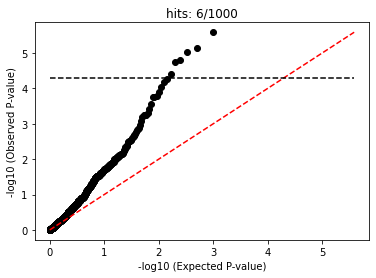

In [753]:
limit = max([max(x), max(y)])
fig, ax = plt.subplots()
plt.scatter(x,y,color='black')
plt.plot([0, limit],[0, limit], "--", color = 'red', zorder=1)
plt.plot([0, limit],[bonf, bonf], "--",color = 'black', zorder=1)
plt.xlabel("-log10 (Expected P-value)")
plt.ylabel("-log10 (Observed P-value)")
plt.title("hits: " + str(len(hits)) + "/" + str(len(true_hits)))
plt.show()

# Simulating in Hail using binary phenotypes

In [882]:
# parameters
h2 = 0.2
pi = None #0.002
n = 1000
K = 0.1 # cases/(cases+controls)

In [885]:
# simulate SNPs 
mt = hl.balding_nichols_model(1, 5000, n, reference_genome='GRCh38')
mt = mt.transmute_entries(GT = ko.set_to_phased_call(mt.GT))
mt = hl.experimental.ldscsim.make_betas(mt, h2, pi = pi)[0]

# standardize SNPs
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

# add noise component
mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
mt = mt.annotate_cols(y=mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))
mt = hl.experimental.ldscsim.binarize(mt, mt.y, K)
print(sum(mt.y_binarized.collect()))

# logistic regression
ht = hl.logistic_regression_rows(
     test='wald',
     y=mt.y_binarized,
     x=mt.GT.n_alt_alleles(),
     covariates=[1])

2022-04-05 15:06:40 Hail: INFO: balding_nichols_model: generating genotypes for 1 populations, 5000 samples, and 1000 variants...


482


2022-04-05 15:06:44 Hail: INFO: Coerced sorted dataset
2022-04-05 15:06:44 Hail: INFO: logistic_regression_rows: running wald on 5000 samples for response variable y,
    with input variable x, and 1 additional covariate...


# Simulation of spike and slab using UKBB genotypes with zero heritability

In [854]:
# parameters
sim = 100
h2 = 0
pi = None 
n = 1000

In [855]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
    consequence_category=ko.csqs_case_builder(
            worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
            use_loftee=True)
        )

In [856]:
mt = hl.experimental.ldscsim.make_betas(mt, h2, pi = pi)[0]
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

In [857]:
# add noise component
mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))

In [858]:
for i in range(sim):
    col = "y" + str(i)
    y = mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2))
    mt = mt.annotate_cols(y = y)
    mt = mt.rename({'y': col})
    
    

# Simulation of compound het effects with Hail

In [338]:
def get_gene(length=5):
    r"""Internal method for getting random genes"""
    return ''.join(random.choices(string.ascii_uppercase, k=length))

In [373]:
# parameters
sim = 100
h2_snp = 0.2
h2_ch = 0.05
pi_snp = None
pi_ch = None

n = 1000

In [449]:
# simulate SNPs 
mt = hl.balding_nichols_model(3, 1000, n, reference_genome='GRCh38')
mt = mt.transmute_entries(GT = ko.set_to_phased_call(mt.GT))
mt = mt.transmute_entries(GT = ko.rand_flip_call(mt.GT))
mt = hl.experimental.ldscsim.make_betas(mt, h2_snp, pi = pi_snp)[0]

# standardize SNPs
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)

# add noise component
#mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
#mt = mt.annotate_cols(y=mt.y_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))

2022-04-06 17:08:59 Hail: INFO: balding_nichols_model: generating genotypes for 3 populations, 1000 samples, and 1000 variants...


(0, 1000)

In [447]:
#mt.filter_rows(hl.agg.call_stats(mt.GT, mt.alleles)[].homozygote_count > 2)
#hl.variant_qc(mt).describe()

TypeError: Invalid '>' comparison, cannot compare expressions of type 'array<int32>' and 'int32'

In [377]:
# need to simulate genes
n_genes = 25
mt = mt.annotate_rows(gene = hl.str(hl.rand_cat([1]*n_genes )))

gene_expr = mt.gene
genes = ko.aggr_phase_count_by_expr(mt, gene_expr)
expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
genes = genes.annotate_entries(
            pKO=expr_pko,
            knockout=expr_ko)

#genes = genes.filter_entries(genes.knockout == "Compound heterozygote")


In [365]:
np.unique(np.array(x))

array(['Compound heterozygote', 'Homozygote'], dtype='<U21')

# simulation if compound het effects in UKBB

In [4]:
def rand_hom_to_het(gt: hl.call, P: float = 0.9, seed = None):
    """ Randomize genotype phase of call
    :param gt: genotype call to be flipped
    :param P: probabily of flipping hom to het
    :param seed: seed for random
    """
    assert str(gt.dtype) == 'call'

    return hl.if_else(
        (gt.n_alt_alleles() == 2),
        hl.if_else(
            (hl.rand_bool(P, seed=seed)),
            hl.if_else(
                (hl.rand_bool(0.5, seed=seed)),
                hl.parse_call("1|0"),
                hl.parse_call("0|1")
            ),
            gt
        ),
        gt
    )

In [4]:
def try_param_h2(x):
    return float(x) if x not in [None, "NA","None"] else None

def try_param_pi(x):
    return float(x) if x not in [0, None, "NA","None"] else None

In [5]:
# parameters
sim = 100
h2_co = 0.1
h2_ko = 0.2
pi_co = 0
pi_ko = 0.1
causal_genes_ko = 5
K = 0
n = 1000
prune_hom_alt = 0.98

In [6]:
h2_beta = 0.3
pi_beta = 0.1
h2_theta = 0.3
pi_theta = 0.1
annotate_knockout_type = True

In [7]:
# Heritability must be specified
h2_co = try_param_h2(h2_co)
h2_ko = try_param_h2(h2_ko)
pi_co = try_param_pi(pi_co)
pi_ko = try_param_pi(pi_ko)
K = float(K)

In [8]:
print(try_param_pi(0))

None


In [37]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')

In [38]:
# annotate with variant consequence
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
consequence_category=ko.csqs_case_builder(
    worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
    use_loftee=True))

In [39]:
# collapse to gene level
gene_expr = mt.consequence.vep.worst_csq_by_gene_canonical.gene_id
mt = ko.aggr_phase_count_by_expr(mt, gene_expr)

In [40]:
# annotate knockout type
expr_pko = ko.calc_prob_ko(mt.hom_alt_n, mt.phased, mt.unphased)
expr_ko = ko.annotate_knockout(mt.hom_alt_n, expr_pko)
mt = mt.annotate_entries(
    pKO=expr_pko, 
    knockout=expr_ko
)

In [41]:
# haplotypes 1 and 2
mt = mt.annotate_entries(
    H1 = 1*((mt.phased.a1 > 0) | (mt.hom_alt_n > 0)),
    H2 = 1*((mt.phased.a2 > 0) | (mt.hom_alt_n > 0)),
)

# combined dosage on a gene
mt = mt.annotate_entries(
    DS = mt.H1 + mt.H2,
    H = 2*(mt.H1 * mt.H2)
)

# normalize haplotypes by total
mt = mt.annotate_rows(**{'stats': hl.agg.stats(mt.DS)})
mt = mt.filter_rows(mt.stats.stdev > 0)
mt = mt.annotate_entries(
    H1_norm=(mt.H1-mt.stats.mean)/mt.stats.stdev,
    H2_norm=(mt.H2-mt.stats.mean)/mt.stats.stdev,
    H_norm=(mt.H-mt.stats.mean)/mt.stats.stdev
)


# make betas (additive effects) and thetas (domincance effects)
mt = hl.experimental.ldscsim.make_betas(mt, h2=h2_theta, pi=pi_theta)[0].rename({"beta":"theta"})
mt = hl.experimental.ldscsim.make_betas(mt, h2=h2_beta, pi=pi_beta)[0]

# additive effetcs from each haplotype
mt = mt.annotate_cols(y_no_noise_H1=hl.agg.sum(mt.beta * mt.H1_norm))
mt = mt.annotate_cols(y_no_noise_H2=hl.agg.sum(mt.beta * mt.H2_norm))
mt = mt.annotate_cols(y_no_noise_sign = 1*hl.sign(mt.y_no_noise_H1 + mt.y_no_noise_H2))

# annotate final effects
if (h2_theta > 0):
    mt = mt.annotate_cols(
        y_no_noise_H=mt.y_no_noise_sign * hl.abs(hl.agg.sum(mt.theta * mt.H_norm)))
    mt = mt.annotate_cols(
        y_no_noise = 
            mt.y_no_noise_H1 + 
            mt.y_no_noise_H2 +  
            mt.y_no_noise_H)
else:
    mt = mt.annotate_cols(
        y_no_noise = 
            mt.y_no_noise_H1 + 
            mt.y_no_noise_H2)

# re-scale genetic contribution
mt = mt.annotate_cols(**{'ystats': hl.agg.stats(mt.y_no_noise)})
mt = mt.annotate_cols(y_no_noise_rescaled = (mt.y_no_noise-mt.ystats.mean)/mt.ystats.stdev)
mt = mt.annotate_cols(y = mt.y_no_noise_rescaled + hl.rand_norm(0, hl.sqrt(1-h2_beta-h2_theta)))


2022-07-10 18:08:06 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-07-10 18:08:26 Hail: INFO: Ordering unsorted dataset with network shuffle


In [42]:
mtt = mt.checkpoint("test_checkpoint.mt", overwrite = True)

2022-07-10 18:08:33 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-07-10 18:09:36 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-07-10 18:09:43 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-07-10 18:10:22 Hail: INFO: wrote matrix table with 339 rows and 10000 columns in 1 partition to test_checkpoint.mt
    Total size: 11.58 MiB
    * Rows/entries: 10.86 MiB
    * Columns: 738.60 KiB
    * Globals: 11.00 B
    * Smallest partition: 339 rows (10.86 MiB)
    * Largest partition:  339 rows (10.86 MiB)


In [20]:
   x
mt = mt.annotate_cols(**{'y_no_noise_stats': hl.agg.stats(mt.y_no_noise)})
mt = 

In [18]:
    mt = mt.annotate_cols(
        y = mt.y_no_noise_H1 + 
            mt.y_no_noise_H2 +  
            mt.y_no_noise_H +
            hl.rand_norm(0, hl.sqrt(1-h2_beta-h2_theta))

In [19]:
mt.describe()

----------------------------------------
Global fields:
    None
----------------------------------------
Column fields:
    's': str
    'y_no_noise_H1': float64
    'y_no_noise_H2': float64
    'y_no_noise_sign': float64
    'y_no_noise_H': float64
    'y': float64
    'y_no_noise': float64
    'y_stats': struct {
        mean: float64, 
        stdev: float64, 
        min: float64, 
        max: float64, 
        n: int64, 
        sum: float64
    }
----------------------------------------
Row fields:
    'gene_id': str
    'stats': struct {
        mean: float64, 
        stdev: float64, 
        min: float64, 
        max: float64, 
        n: int64, 
        sum: float64
    }
    'theta': float64
    'beta': float64
----------------------------------------
Entry fields:
    'phased': struct {
        a1: int64, 
        a2: int64, 
        n: int64
    }
    'unphased': struct {
        n: int64
    }
    'hom_alt_n': int64
    'pKO': float64
    'knockout': str
    'H1': int3

In [42]:
mt = io.import_table("data/unphased/wes_union_calls/ukb_eur_wes_union_calls_200k_chr19.vcf.bgz","vcf")

In [ ]:
loci = mt.locus.contig.collect()

2022-06-30 18:22:29 Hail: INFO: Coerced sorted dataset


In [11]:
if h2_co > 0:
    # simulate betas (coding region)
    print("Simulating coding variant phenotype with h2=%s and pi=%s" % (h2_co, pi_co))
    mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
    mt = hl.experimental.ldscsim.make_betas(mt, h2=h2_co, pi=pi_co)[0]
    mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)
    mt = mt.annotate_cols(y_no_noise_co=hl.agg.sum(mt.beta * mt['norm_gt']))

In [12]:
# annotate with CH effect
if h2_ko > 0:

    # simulate compound het effects
    print("Simulating compound het phenotype with h2=%s and pi=%s" % (h2_ko, pi_ko))

    # prune away knockedout owed to homozygote alternates
    gene_mt = mt
    if prune_hom_alt:
        prune_hom_alt = float(prune_hom_alt)
        gene_mt = gene_mt.transmute_entries(GT = ko.rand_hom_to_het(gene_mt.GT, prune_hom_alt))
        
    # generate gene x sample matrix
    gene_expr = gene_mt.consequence.vep.worst_csq_by_gene_canonical.gene_id
    
    genes = ko.aggr_phase_count_by_expr(gene_mt, gene_expr)
    expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
    expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
    genes = genes.annotate_entries(pKO=expr_pko, knockout=expr_ko)
    
    n = genes.count()[0]
    if pi_ko:
        expt_causal_genes = n * pi_ko
        print("Expecting %0.2f of %0.0f genes to be causal." % (expt_causal_genes, n))

    # simulate thetas (CH effects).
    genes = genes.filter_rows(hl.agg.stats(genes.pKO).stdev>0)
    genes = ko.make_thetas(genes, h2=h2_ko, pi=pi_ko)
    genes = ko.normalize_by_name(genes, "pKO")
    genes = genes.filter_rows(genes.theta > 0)
    genes = genes.annotate_cols(y_no_noise_ko=hl.agg.sum(genes.theta * genes.norm_pKO))
    genes = genes.annotate_cols(y = genes.y_no_noise_ko + hl.rand_norm(0, hl.sqrt(1-h2_ko)))

    if pi_ko:
        found_causal_genes = np.sum(np.array(genes.theta.collect()) != 0)
        print("Observed %0.2f of %0.0f causal genes.." % (found_causal_genes, n))
    
    
    # return thetas for genes and samples
    ht = genes.select_rows('theta').select_entries(*['pKO','knockout'])
    #ht.entries().flatten().export(out_prefix + "_genes.tsv.gz")

    # annotate original matrix with thetas from gene x sample matrix
    mt = mt.annotate_cols(y_no_noise_ko = genes.index_cols(mt.col_key).y_no_noise_ko)
    #x = mt.y_no_noise_ko.collect()
    
    


    

Simulating compound het phenotype with h2=0.2 and pi=0.1


2022-04-25 21:27:44 Hail: INFO: Ordering unsorted dataset with network shuffle


Expecting 35.40 of 354 genes to be causal.


2022-04-25 21:28:14 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-04-25 21:28:29 Hail: INFO: Ordering unsorted dataset with network shuffle


Observed 14.00 of 354 causal genes..


2022-04-25 21:29:15 Hail: WARN: cols(): Resulting column table is sorted by 'col_key'.
    To preserve matrix table column order, first unkey columns with 'key_cols_by()'


In [13]:
genes = genes.checkpoint('genes_checkpoint.mt', overwrite = True)

2022-04-25 21:30:00 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-04-25 21:31:03 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-04-25 21:31:53 Hail: INFO: wrote matrix table with 14 rows and 10000 columns in 1 partition to genes_checkpoint.mt
    Total size: 606.98 KiB
    * Rows/entries: 426.03 KiB
    * Columns: 180.94 KiB
    * Globals: 11.00 B
    * Smallest partition: 14 rows (426.03 KiB)
    * Largest partition:  14 rows (426.03 KiB)


In [14]:
#c_mt = mt.checkpoint('mt_checkpoint.mt', overwrite = True)

2022-04-25 21:32:06 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-04-25 21:33:05 Hail: INFO: wrote matrix table with 86799 rows and 10000 columns in 1 partition to mt_checkpoint.mt


In [15]:
mt = c_mt

In [21]:
#x = mt.annotate_cols(defined = hl.is_defined(mt.y_no_noise_ko)).defined.collect()

In [24]:
#sum(x)

In [25]:
# add noise
if h2_co == 0 and h2_ko == 0:
    mt = mt.annotate_cols(y_cts=hl.rand_norm(0, hl.sqrt(1)))
elif h2_ko > 0 and h2_co > 0:
    mt = mt.annotate_cols(y_cts=mt.y_no_noise_co +
                mt.y_no_noise_ko + hl.rand_norm(0, hl.sqrt(1-h2_ko-h2_co)))
elif h2_ko > 0 and h2_co is None:
    mt = mt.annotate_cols(y_cts = mt.y_no_noise_ko +
                hl.rand_norm(0, hl.sqrt(1-h2_ko)))
elif h2_ko is None and h2_co > 0:
    mt = mt.annotate_cols(y_cts = mt.y_no_noise_snp +
                hl.rand_norm(0, hl.sqrt(1-h2_co)))
    

In [163]:
ht = genes.entries()
sids_y = np.array(ht.filter(ht.y_no_noise_ko > 0).s.collect())
sids_theta = np.array(ht.filter(ht.theta == 0).s.collect())

In [164]:
#np.unique(sids_y)
np.unique(sids_theta).shape

(10000,)

In [109]:
genes.describe()

----------------------------------------
Global fields:
    None
----------------------------------------
Column fields:
    's': str
    'y_no_noise_ko': float64
----------------------------------------
Row fields:
    'gene_id': str
    'stats': struct {
        mean: float64, 
        stdev: float64, 
        min: float64, 
        max: float64, 
        n: int64, 
        sum: float64
    }
    'theta': float64
----------------------------------------
Entry fields:
    'phased': struct {
        a1: int64, 
        a2: int64, 
        n: int64
    }
    'unphased': struct {
        n: int64
    }
    'hom_alt_n': int64
    'pKO': float64
    'knockout': str
    'norm_pKO': float64
----------------------------------------
Column key: ['s']
Row key: ['gene_id']
----------------------------------------


In [113]:
# perform linear regression (need a few more cores)
#fit = hl.linear_regression_rows(y=genes.y_no_noise_ko,
#                          x=genes.pKO,
#                          covariates=[1])

In [159]:
x = genes.y_no_noise_ko.collect()

2022-04-19 15:35:41 Hail: INFO: Ordering unsorted dataset with network shuffle


In [160]:
x

[-0.6513285168284701,
 0.22201105677212324,
 -0.009803072719417659,
 -0.16115322771574783,
 -0.12395998695039454,
 0.06535759915529799,
 0.30740374462607356,
 -0.014970533109137011,
 0.22201105677212324,
 0.22201105677212324,
 0.22529528529820828,
 -0.16115322771574783,
 0.0615817551900848,
 0.17901763621904554,
 -0.43539553418116295,
 -0.2923186331003036,
 0.09868950395461057,
 0.24436126803841302,
 -0.02906900360025272,
 -0.1898187245699124,
 0.07930310182678457,
 0.25911880553664896,
 -0.31637561845061957,
 0.32172559116438415,
 0.1558553901260064,
 -0.3392257055299416,
 0.3530598700136741,
 0.43538562822813176,
 0.027873506523948245,
 -0.2889117352706111,
 -0.02906900360025272,
 0.1454587684729014,
 0.03646513935430187,
 0.22201105677212324,
 -0.37179827872634474,
 0.32172559116438415,
 -0.13482086412242655,
 -0.036845380348494244,
 0.08941458450561399,
 0.07930310182678457,
 -0.02754915375177694,
 0.32172559116438415,
 0.052287363073529915,
 0.1423487996698079,
 0.2076892102338126

In [146]:
h2_ko == 0

False

In [147]:
5/n

0.014124293785310734

False

In [93]:
genes.select_rows('theta').select_entries('pKO').entries().flatten().describe()

----------------------------------------
Global fields:
    None
----------------------------------------
Row fields:
    'gene_id': str 
    'theta': float64 
    's': str 
    'y_no_noise_snp': float64 
    'y_no_noise_ko': float64 
    'pKO': float64 
----------------------------------------
Key: []
----------------------------------------


In [41]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
    consequence_category=ko.csqs_case_builder(
            worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
            use_loftee=True)
        )

# subset to current csqs category
items = ['pLoF','damaging_missense']
mt = mt.filter_rows(hl.literal(set(items)).contains(mt.consequence_category))

print(mt.aggregate_entries(hl.agg.counter(mt.GT.is_hom_var())))
mt = mt.transmute_entries(GT = rand_hom_to_het(mt.GT, 0.95))
print(mt.aggregate_entries(hl.agg.counter(mt.GT.is_hom_var())))

#mt = mt.annotate_rows(n_alt_hom = hl.agg.call_stats(mt.GT, mt.alleles).homozygote_count[1])
#mt = mt.filter_rows(mt.n_alt_hom > 0)
#print(mt.count())

frozendict({False: 36309398, True: 602})
frozendict({False: 36309965, True: 35})


In [37]:
mt.aggregate_entries(hl.agg.counter(mt.GT.is_hom_var()))

frozendict({False: 6157496, True: 2504})

In [39]:

2521693 * 0.999


2519171.307

In [42]:
# get betas
mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
mt = hl.experimental.ldscsim.make_betas(mt, h2 = h2_snp, pi = pi_snp)[0]
mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)
mt = mt.annotate_cols(y_no_noise_snp=hl.agg.sum(mt.beta * mt['norm_gt']))


In [43]:
# get thetas
gene_expr = mt.consequence.vep.worst_csq_by_gene_canonical.gene_id
genes = ko.aggr_phase_count_by_expr(mt, gene_expr)
expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
genes = genes.annotate_entries(
            pKO=expr_pko,
            knockout=expr_ko)

In [46]:
# 
counts = genes.aggregate_entries(hl.agg.counter(genes.knockout))


2022-04-06 17:42:15 Hail: INFO: Ordering unsorted dataset with network shuffle


In [48]:
counts = genes.aggregate_entries(hl.agg.counter(genes.knockout))
n_homs = counts['Homozygote']
n_ch = counts['Compound heterozygote']

In [49]:
n_ch 

9

In [50]:
n_homs

35

In [403]:
#x = genes
genes = genes.filter_rows(hl.agg.stats(genes.pKO).stdev>0)
genes = normalize_by_name(genes, "pKO")
genes = make_thetas(genes, h2 = h2_ch, pi = pi_ch)
genes = genes.annotate_cols(y_no_noise=hl.agg.sum(genes.theta * genes.norm_pKO))

2022-04-06 15:19:53 Hail: INFO: Ordering unsorted dataset with network shuffle


In [404]:
mt = mt.annotate_cols(y_no_noise_ch = genes.index_cols(mt.col_key).y_no_noise)
mt = mt.annotate_cols(y=mt.y_no_noise_snp + mt.y_no_noise_ch + hl.rand_norm(0, hl.sqrt(1-h2_ch-h2_snp)))

In [51]:
#mt = mt.checkpoint('data/tmp/mt_checkpoint.mt', overwrite = True)
#x = mt
mt = x


NameError: name 'x' is not defined

In [407]:
print(np.var(mt.y.collect()))

test = mt.y_no_noise_snp + mt.y_no_noise_ch
print(np.var(mt.y_no_noise_snp.collect()))
print(np.var(mt.y_no_noise_ch.collect()))


#np.var(test.collect())

0.9733276930148409
0.19552562989109723
0.051731041663673274


0.05

In [77]:
def normalize_by_name(mt, name):
    """Normalize entry to have mean of zero and variance of 1"""
    mt = mt.annotate_rows(**{'stats': hl.agg.stats(mt[name])})
    mt = mt.annotate_entries(
        norm=(mt[name]-mt.stats.mean)/mt.stats.stdev)
    mt = mt.rename({"norm" : "norm_" + str(name)})
    return(mt)


def make_thetas(mt, h2, pi = None):
    """ Make thetas (effect sizes) for genes (gene x sample matrix) with
    either infintesimal or spike and slab model. 
    """
    
    M = mt.count()[0]
    pi_temp = 1 if pi == None else pi
    mt = mt.annotate_rows(
        theta = hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2/(M*pi_temp))))
    return(mt)

#test = make_thetas(genes, "pKO", h2 = 0.1, pi = 0.05).theta.collect()
#print(np.size(np.where(np.array(test) == float(0))))
#print(np.size(np.where(np.array(test) != float(0))))

[0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 -1.369432884982232,
 -1.369432884982232,
 0.6236290928699466,
 -1.369432884982232,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928699466,
 0.6236290928

In [185]:
genes = genes.annotate_rows(rnd = hl.rand_bool(0.25))
#hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2/(M*pi_temp)))

In [186]:
genes.rnd.show()

,
gene_id,rnd
str,bool
"""ENSG00000141956""",False
"""ENSG00000141959""",False
"""ENSG00000142149""",False
"""ENSG00000142156""",False
"""ENSG00000142166""",True
"""ENSG00000142168""",False
"""ENSG00000142173""",False
"""ENSG00000142182""",True


In [141]:
M = genes.count()[0]
hl.rand_bool(pi_temp).show()

#pi_temp = 1 if pi == None else pi
#genes=genes.annotate_rows(
#    theta = hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2_ch/(M*pi_temp))))
#genes = genes.annotate_cols(y_ch_no_noise=hl.agg.sum(genes.theta * genes.pKO))

""
""
bool
True


In [88]:
mt = genes
mt = mt.annotate_rows(**{'stats': hl.agg.stats(mt.pKO)})
mt = mt.filter_rows(mt.stats.stdev>0)
mt = mt.annotate_entries(norm=(mt.pKO-mt.stats.mean)/mt.stats.stdev)

In [89]:
test = mt.norm.collect()

In [90]:
print(np.var(test))

0.9999999999999991


0.9999999999999991


In [23]:
genes.count()

2022-04-06 13:19:41 Hail: INFO: Ordering unsorted dataset with network shuffle


(353, 10000)

In [13]:
# add up effects
mt = mt.annotate_cols(y=mt.y_snp_no_noise + mt.y_ch_no_noise + hl.rand_norm(0, hl.sqrt(1-h2)))

In [70]:
# need to test

In [71]:
y = mt.y.collect()

In [72]:
np.var(y)

0.9882753962510127

In [ ]:
def make_thetas(mt, h2, pi=None, genes):
    M = genes.count()
    pi_temp = 1 if pi == [None] else pi[0]
    mt = mt.annotate_rows(thetas=hl.rand_bool(
        pi_temp)*hl.rand_norm(0, hl.sqrt(h2[0]/(M*pi_temp))))
    return mt, pi, rg

In [ ]:
M = genes.count()
pi_temp = 1 if pi == [None] else pi[0]
thetas=hl.rand_bool(pi_temp)*hl.rand_norm(0, hl.sqrt(h2[0]/(M*pi_temp))))




In [ ]:
ht = hl.import_table('data/knockouts/alt/ukb_eur_wes_200k_chr21_maf0to5e-2_pLoF_damaging_missense.tsv.gz', force = True)
ht = ht.filter(ht.knockout == "Compound heterozygote") 
ht = ht.filter(ht.gene_id == "ENSG00000142173") # ENSG00000142173 16 knockouts #ht.aggregate(hl.agg.counter(ht.gene_id))
sids = ht.s.collect()
genes = ht.gene_id.collect()

# Sim full model

In [8]:
def make_y_region(mt: hl.MatrixTable, h2, pi, region: list()):
    mt = mt.filter_rows(hl.literal(set(region)).contains(mt.consequence_category))
    mt = mt.filter_rows(hl.agg.stats(mt.GT.n_alt_alleles()).stdev>0)
    mt = hl.experimental.ldscsim.make_betas(mt, h2=h2, pi=pi)[0]
    mt = hl.experimental.ldscsim.normalize_genotypes(mt.GT)
    mt = mt.annotate_cols(y_no_noise=hl.agg.sum(mt.beta * mt['norm_gt']))
    return(mt)

In [10]:
prune_hom_alt = 0.99
seed = 42
h2_nc = 0.05
h2_co = 0.15
h2_ko = 0.30
pi_nc = None
pi_co = None
pi_ko = None
K = 0.1

In [11]:
mt = hl.read_matrix_table('data/simulation/data/ukb_eur_10000_samples_chr21.mt')
mt = mt.explode_rows(mt.consequence.vep.worst_csq_by_gene_canonical)
mt = mt.annotate_rows(
    consequence_category=ko.csqs_case_builder(
            worst_csq_expr=mt.consequence.vep.worst_csq_by_gene_canonical,
            use_loftee=True)
        )

In [13]:
mt_nc = make_y_region(mt, h2_nc, pi_nc, ["non_coding"])

In [15]:
mt_co = make_y_region(mt, h2_co, pi_co, ["pLoF","damaging_missense"])

In [161]:
# prune away knockedout owed to homozygote alternates
gene_mt = mt
if prune_hom_alt:
    prune_hom_alt = float(prune_hom_alt)
    gene_mt = gene_mt.transmute_entries(GT = ko.rand_hom_to_het(gene_mt.GT, prune_hom_alt))

# generate gene x sample matrix
gene_expr = gene_mt.consequence.vep.worst_csq_by_gene_canonical.gene_id
genes = ko.aggr_phase_count_by_expr(gene_mt, gene_expr)
expr_pko = ko.calc_prob_ko(genes.hom_alt_n, genes.phased, genes.unphased)
expr_ko = ko.annotate_knockout(genes.hom_alt_n, expr_pko)
genes = genes.annotate_entries(pKO=expr_pko, knockout=expr_ko)

#n = genes.count()[0]
#if pi_ko:
#    expt_causal_genes = n * pi_ko
#    print("Expecting %0.2f of %0.0f genes to be causal." % (expt_causal_genes, n))



In [162]:
# simulate thetas (CH effects).
genes = genes.filter_rows(hl.agg.stats(genes.pKO).stdev>0)
genes = ko.normalize_by_name(genes, "pKO")
genes = ko.make_thetas(genes, h2=h2_ko, pi=pi_ko)
genes = genes.annotate_cols(y_no_noise_ko=hl.agg.sum(genes.theta * genes.norm_pKO))

2022-04-19 15:38:19 Hail: INFO: Ordering unsorted dataset with network shuffle


# debug

In [176]:
#ht = hl.import_table("data/simulation/phenotypes_only_genes/ukb_eur_h2_0.0_0.09_pi_0.0_0.1_K_0.1_chr21_1_genes_new.tsv.gz", force = True, impute = True)

In [177]:
#mt = ht.to_matrix_table(row_key = ['gene_id'], col_key = ['s'], row_fields = ["theta"], col_fields = ['y_no_noise_ko','y'])

In [178]:
#mt = mt.checkpoint('test_checkpoint.mt', overwrite = True)

In [242]:
mt = hl.read_matrix_table('data/simulation/phenotypes_only_genes/ukb_eur_h2_0.0_0.09_pi_0.0_0.1_K_0.1_chr21_1_genes_w_mt.mt/')

In [251]:
m = mt
m = m.annotate_cols(test = hl.agg.sum(m.theta * m.norm_pKO))
m = m.filter_cols(m.s == "1945684") # error (also 2613995)
#m = m.filter_cols(m.s ==  "1797285") # no error
m.count()

(37, 1)

In [252]:
m.show()

+-------------------+---------------------+---------------------+--------------------+----------------------+---------------------+---------------+
| gene_id           | '1945684'.phased.a1 | '1945684'.phased.a2 | '1945684'.phased.n | '1945684'.unphased.n | '1945684'.hom_alt_n | '1945684'.pKO |
+-------------------+---------------------+---------------------+--------------------+----------------------+---------------------+---------------+
| str               |               int64 |               int64 |              int64 |                int64 |               int64 |       float64 |
+-------------------+---------------------+---------------------+--------------------+----------------------+---------------------+---------------+
| "ENSG00000141956" |                   1 |                   0 |                  1 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000141959" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000142156" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000142173" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000142185" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000142192" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000142197" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000142207" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000155313" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000156253" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000156284" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000156304" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000157551" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000157578" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000157601" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000159082" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000159261" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000160183" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000160190" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000160208" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "ENSG00000160224" |                   1 |                   0 |                  1 |                    1 |                   0 |      5.00e-01 |
| "ENSG00000160233" |                   0 |                   0 |                  0 |                    0 |                   0 |      0.00e+00 |
| "E

In [253]:
m.test.show()

,
s,test
str,float64
"""1945684""",-3.47e-05


In [254]:
m.y_no_noise_ko.show()

,
s,y_no_noise_ko
str,float64
"""1945684""",5.96e+00


In [255]:
m.annotate_cols(y_no_noise_ko_new = hl.agg.sum(m.theta*m.norm_pKO)).y_no_noise_ko_new.show()

,
s,y_no_noise_ko_new
str,float64
"""1945684""",-3.47e-05


In [248]:
vals = (m.theta * m.norm_pKO).collect()
sum(vals)

13.74677981008287

In [250]:
print(m.y_no_noise_ko.collect())
#print(m.y_no_noise_ko_new.collect())

[13.745050056670404]


In [80]:
thetas = np.array(m.theta.collect())
norm_pko = np.array(m.norm_pKO.collect())

In [84]:
np.dot(norm_pko, thetas)

-0.0002852080962

In [71]:
thetas

array([-0.      ,  0.      ,  0.      , -0.      ,  0.093872,  0.      ,
        0.      , -0.      ,  0.      , -0.      , -0.      , -0.      ,
        0.      , -0.      ,  0.      ,  0.      ,  0.      , -0.040062,
        0.      , -0.      , -0.      , -0.081772, -0.      ,  0.      ,
       -0.      ,  0.      , -0.      ,  0.      , -0.      ,  0.      ,
       -0.      ,  0.      ,  0.      , -0.060407, -0.013541, -0.      ,
       -0.      ])

## 

In [263]:
mt = hl.balding_nichols_model(1, 5000, 37, reference_genome='GRCh38')
mt = mt.annotate_rows(gene_id = hl.delimit([hl.str(mt.locus.position),mt.alleles[0], mt.alleles[1]], '_'))
mt = mt.key_rows_by(mt.gene_id)
mt = mt.annotate_entries(pKO = mt.GT.n_alt_alleles()/2)
mt = mt.annotate_cols(s = mt.sample_idx)
mt = mt.drop(*['alleles','locus','bn', 'pop'])
mt = mt.key_cols_by(mt.s)
gene_mt = mt

2022-04-25 15:30:37 Hail: INFO: balding_nichols_model: generating genotypes for 1 populations, 5000 samples, and 37 variants...


In [261]:
prune_hom_alt = float(prune_hom_alt)
gene_mt = gene_mt.transmute_entries(GT = ko.rand_hom_to_het(gene_mt.GT, prune_hom_alt))

In [264]:
genes = gene_mt
genes = genes.filter_rows(hl.agg.stats(genes.pKO).stdev>0)
genes = ko.make_thetas(genes, h2=h2_ko, pi=pi_ko)
genes = ko.normalize_by_name(genes, "pKO")

In [265]:
genes = genes.annotate_entries(y_theta_pKO = genes.theta * genes.pKO)
genes = genes.annotate_cols(y_no_noise_ko=hl.agg.sum(genes.y_theta_pKO))
genes = genes.annotate_cols(y = genes.y_no_noise_ko + hl.rand_norm(0, hl.sqrt(1-h2_ko)))

In [270]:
genes = genes.checkpoint("another_genes.mt", overwrite = True)

2022-04-25 15:32:59 Hail: INFO: Ordering unsorted dataset with network shuffle
2022-04-25 15:33:00 Hail: INFO: wrote matrix table with 37 rows and 5000 columns in 8 partitions to another_genes.mt
    Total size: 433.63 KiB
    * Rows/entries: 357.01 KiB
    * Columns: 76.61 KiB
    * Globals: 11.00 B
    * Smallest partition: 5 rows (34.96 KiB)
    * Largest partition:  5 rows (55.12 KiB)


In [272]:
genes.show()

+----------+------+----------+------------+---------------+------+----------+------------+---------------+------+----------+------------+---------------+
| gene_id  | 0.GT |    0.pKO | 0.norm_pKO | 0.y_theta_pKO | 1.GT |    1.pKO | 1.norm_pKO | 1.y_theta_pKO | 2.GT |    2.pKO | 2.norm_pKO | 2.y_theta_pKO |
+----------+------+----------+------------+---------------+------+----------+------------+---------------+------+----------+------------+---------------+
| str      | call |  float64 |    float64 |       float64 | call |  float64 |    float64 |       float64 | call |  float64 |    float64 |       float64 |
+----------+------+----------+------------+---------------+------+----------+------------+---------------+------+----------+------------+---------------+
| "10_A_C" | 1/1  | 1.00e+00 |   2.61e-01 |      1.61e-01 | 1/1  | 1.00e+00 |   2.61e-01 |      1.61e-01 | 1/1  | 1.00e+00 |   2.61e-01 |      1.61e-01 |
| "11_A_C" | 0/0  | 0.00e+00 |  -1.00e+00 |     -0.00e+00 | 0/1  | 5.00e-01 |   4.95e-01 |     -3.95e-03 | 0/1  | 5.00e-01 |   4.95e-01 |     -3.95e-03 |
| "12_A_C" | 1/1  | 1.00e+00 |   1.47e+00 |      0.00e+00 | 1/1  | 1.00e+00 |   1.47e+00 |      0.00e+00 | 0/1  | 5.00e-01 |   5.64e-02 |      0.00e+00 |
| "13_A_C" | 0/1  | 5.00e-01 |  -1.43e+00 |      0.00e+00 | 1/1  | 1.00e+00 |   5.89e-01 |      0.00e+00 | 1/1  | 1.00e+00 |   5.89e-01 |      0.00e+00 |
| "14_A_C" | 0/1  | 5.00e-01 |   1.23e+00 |      0.00e+00 | 0/1  | 5.00e-01 |   1.23e+00 |      0.00e+00 | 0/1  | 5.00e-01 |   1.23e+00 |      0.00e+00 |
| "15_A_C" | 0/1  | 5.00e-01 |  -1.16e+00 |     -1.11e-01 | 1/1  | 1.00e+00 |   6.60e-01 |     -2.23e-01 | 0/1  | 5.00e-01 |  -1.16e+00 |     -1.11e-01 |
| "16_A_C" | 1/1  | 1.00e+00 |   7.71e-01 |      0.00e+00 | 0/0  | 0.00e+00 |  -2.60e+00 |      0.00e+00 | 0/1  | 5.00e-01 |  -9.17e-01 |      0.00e+00 |
| "17_A_C" | 0/1  | 5.00e-01 |   6.35e-01 |      0.00e+00 | 0/1  | 5.00e-01 |   6.35e-01 |      0.00e+00 | 0/1  | 5.00e-01 |   6.35e-01 |      0.00e+00 |
| "18_A_C" | 1/1  | 1.00e+00 |   1.95e+00 |     -0.00e+00 | 0/0  | 0.00e+00 |  -1.03e+00 |     -0.00e+00 | 0/1  | 5.00e-01 |   4.63e-01 |     -0.00e+00 |
| "19_A_C" | 1/1  | 1.00e+00 |   1.03e+00 |      0.00e+00 | 1/1  | 1.00e+00 |   1.03e+00 |      0.00e+00 | 0/1  | 5.00e-01 |  -4.46e-01 |      0.00e+00 |
| "1_A_C"  | 1/1  | 1.00e+00 |   6.82e-01 |      0.00e+00 | 1/1  | 1.00e+00 |   6.82e-01 |      0.00e+00 | 1/1  | 1.00e+00 |   6.82e-01 |      0.00e+00 |
| "20_A_C" | 1/1  | 1.00e+00 |   7.80e-01 |     -0.00e+00 | 0/1  | 5.00e-01 |  -8.86e-01 |     -0.00e+00 | 1/1  | 1.00e+00 |   7.80e-01 |     -0.00e+00 |
| "21_A_C" | 1/1  | 1.00e+00 |   6.02e-01 |      0.00e+00 | 1/1  | 1.00e+00 |   6.02e-01 |      0.00e+00 | 0/1  | 5.00e-01 |  -1.38e+00 |      0.00e+00 |
| "22_A_C" | 0/1  | 5.00e-01 |   1.14e-01 |     -0.00e+00 | 1/1  | 1.00e+00 |   1.54e+00 |     -0.00e+00 | 0/1  | 5.00e-01 |   1.14e-01 |     -0.00e+00 |
| "23_A_C" | 0/1  | 5.00e-01 |   5.07e-01 |     -1.97e-01 | 0/1  | 5.00e-01 |   5.07e-01 |     -1.97e-01 | 0/0  | 0.00e+00 |  -1.00e+00 |     -0.00e+00 |
| "24_A_C" | 0/0  | 0.00e+00 |  -2.31e+00 |      0.00e+00 | 1/1  | 1.00e+00 |   8.57e-01 |      0.00e+00 | 1/1  | 1.00e+00 |   8.57e-01 |      0.00e+00 |
| "25_A_C" | 0/1  | 5.00e-01 |   9.27e-02 |     -0.00e+00 | 0/1  | 5.00e-01 |   9.27e-02 |     -0.00e+00 | 0/0  | 0.00e+00 |  -1.32e+00 |     -0.00e+00 |
| "26_A_C" | 1/1  | 1.00e+00 |   2.58e-01 |     -0.00e+00 | 1/1  | 1.00e+00 |   2.58e-01 |     -0.00e+00 | 1/1  | 1.00e+00 |   2.58e-01 |     -0.00e+00 |
| "27_A_C" | 1/1  | 1.00e+00 |   8.40e-01 |     -0.00e+00 | 1/1  | 1.00e+00 |   8.40e-01 |     -0.00e+00 | 0/1  | 5.00e-01 |  -7.67e-01 |     -0.00e+00 |
| "28_A_C" | 0/1  | 5.00e-01 |  -1.01e-02 |      0.00e+00 | 0/0  | 0.00e+00 |  -1.41e+00 |      0.00e+00 | 1/1  | 1.00e+00 |   1.39e+00 |      0.00e+00 |
| "29_A_C" | 0/1  | 5.00e-01 |  -1.43e-01 |     -0.00e+00 | 0/1  | 5.00e-01 |  -1.43e-01 |     -0.00e+00 | 0/1  | 5.00e-01 |  -1.43e-01 |     -0.00e+0

In [2]:
def make_beta_with_effect_size(mt, beta, pi = None):
    """ Make specified effect sizes for genes (gene x sample matrix)
    regardless of final heritability.
    """
    
    pi_temp = 1 if pi == None else pi
    mt = mt.annotate_rows(
        theta = hl.rand_bool(pi_temp)*beta)
    return(mt)